# Using the `cyclic_point()` Tool In WxData

In this example, we will download the initial frame of the ECMWF IFS 

1) We will query for 500 mb geopotential height

2) We will then use the `cyclic_point()` tool to fix the 180-line degree data gap issue

3) We will then plot this data as a polar sterographic in matplotlib

4) Since we recently downloaded ECMWF IFS data in another notebook (within the time the scanner will not let it update) - We will demonstrate setting `clear_data=True` since we are downloading a different subset of the data

# Imports

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

from wxdata import ecmwf_ifs, cyclic_point
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER

In [2]:
ifs = ecmwf_ifs(final_forecast_hour=0,
                southern_bound=30,
                level_type='pressure',
                variables=['geopotential height'],
                levels=[500],
               clear_data=True)


By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0).
Please attribute ECMWF when downloading this data.


20260303180000-0h-scda-fc.grib2:   0%|          | 0.00/394k [00:00<?, ?B/s]

ECMWF IFS Download Complete.
ECMWF IFS Data Processing...
ECMWF IFS Data Processing Complete.


In [3]:
ifs

<xarray.Dataset> Size: 1MB
Dimensions:              (step: 1, latitude: 241, longitude: 1440)
Coordinates:
    time                 datetime64[ns] 8B 2026-03-03T18:00:00
  * step                 (step) float64 8B 0.0
    isobaricInhPa        float64 8B ...
  * latitude             (latitude) float64 2kB 90.0 89.75 89.5 ... 30.25 30.0
  * longitude            (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time           datetime64[ns] 8B ...
Data variables:
    geopotential_height  (step, latitude, longitude) float32 1MB dask.array<chunksize=(1, 241, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-03T22:24 GRIB to CDM+CF via cfgrib-0.9.1...

# Using the `cyclic_point()` Tool To Resolve The 180-line

In [4]:
geopotential_height, longitude = cyclic_point(ifs,
                                   'geopotential_height')

In [5]:
geopotential_height

masked_array(
  data=[[[5216.086, 5216.086, 5216.086, ..., 5216.086, 5216.086,
          5216.086],
         [5220.586, 5220.586, 5220.586, ..., 5220.586, 5220.586,
          5220.586],
         [5222.586, 5222.086, 5222.086, ..., 5222.586, 5222.586,
          5222.586],
         ...,
         [5629.586, 5633.586, 5637.086, ..., 5620.586, 5625.586,
          5629.586],
         [5638.086, 5642.086, 5645.586, ..., 5630.586, 5634.586,
          5638.086],
         [5646.586, 5650.586, 5653.586, ..., 5639.586, 5643.086,
          5646.586]]],
  mask=False,
  fill_value=np.float64(1e+20),
  dtype=float32)

In [6]:
longitude

masked_array(data=[-180.  , -179.75, -179.5 , ...,  179.5 ,  179.75,
                    180.  ],
             mask=False,
       fill_value=1e+20)

# Plot Out Data

In [7]:
# Convert our valid time so we can add it into our f-string
init_time = ifs['time'].values
init_time = pd.to_datetime(init_time)

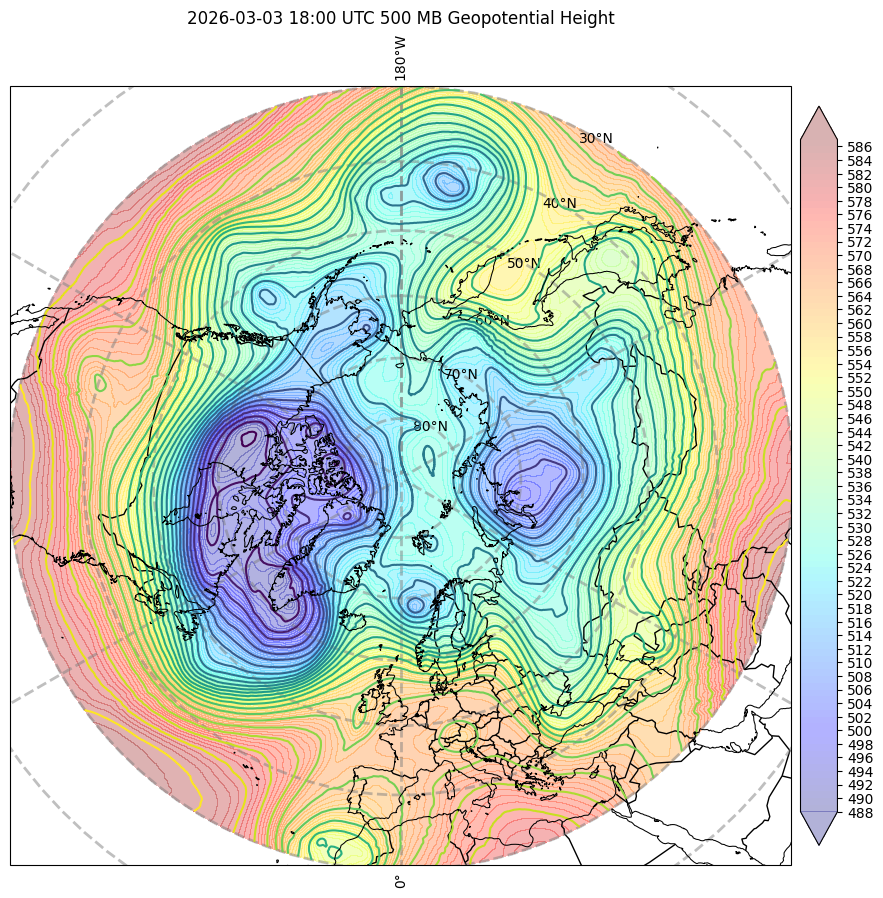

In [8]:
# Create our figure object
fig = plt.figure(figsize=(12,12))

# Create out axis and map coordinates reference system
ax = fig.add_subplot(1,1,1, projection=ccrs.NorthPolarStereo())

# Set our bounds and data coordinate reference system
ax.set_extent([-180, 180, 30, 90], ccrs.PlateCarree())

# Add coastlines for the outline of the coasts
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=9)

# Add our country borders
ax.add_feature(cfeature.BORDERS, linestyle='-', zorder=2)

# Create Our Title
ax.set_title(f"{init_time.strftime('%Y-%m-%d %H:00 UTC')} 500 MB Geopotential Height")

# Plot our gridlines
gl = ax.gridlines(draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False # Disable top labels
gl.ylabels_right = False # Disable right labels
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Create our increments for our filled and line contours
filled_contour_levels = np.arange(int(round(np.nanmin(geopotential_height[0, :, :]/10), 0)), (int(round(np.nanmax(geopotential_height[0, :, :]/10), 0)) + 1), 1)
contour_levels = filled_contour_levels[::4]

# Plot our contour data
ax.contour(longitude, 
            ifs['latitude'], 
            geopotential_height[0, :, :]/10, 
            transform=ccrs.PlateCarree(),
            levels=contour_levels,
            zorder=2,
            alpha=1)

# Plot our filled contour data
cs = ax.contourf(longitude, 
            ifs['latitude'], 
            geopotential_height[0, :, :]/10, 
            cmap='jet', 
            transform=ccrs.PlateCarree(),
            levels=filled_contour_levels,
            alpha=0.3,
            extend='both')

# Create our colorbar
fig.colorbar(cs, shrink=0.8, pad=0.01, ticks=np.arange(488, 588, 2))